# Smart Crop Recommendation System

N → نسبة النيتروجين
P → نسبة الفوسفور
K → نسبة البوتاسيوم
temperature → درجة الحرارة
humidity → الرطوبة
ph → قيمة الـpH
rainfall → كمية الأمطار

##  Dataset


In [357]:
import kagglehub
dataset_path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
Dataset downloaded to: /kaggle/input/crop-recommendation-dataset


In [358]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

In [359]:
SEED = 42
np.random.seed(SEED)

In [360]:
csv_path = os.path.join(dataset_path, "Crop_recommendation.csv")
df = pd.read_csv(csv_path)

In [361]:
df.shape

(2200, 8)

In [362]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


##  Data Cleaning

In [363]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [364]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [365]:
df.duplicated().sum()

np.int64(0)

In [366]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [367]:
df["label"].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


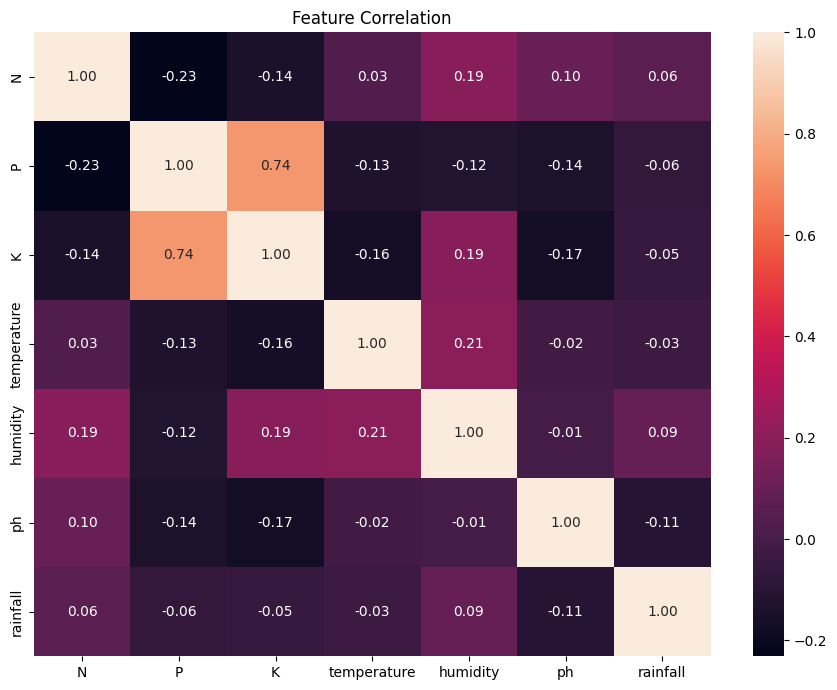

In [368]:
numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f")
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

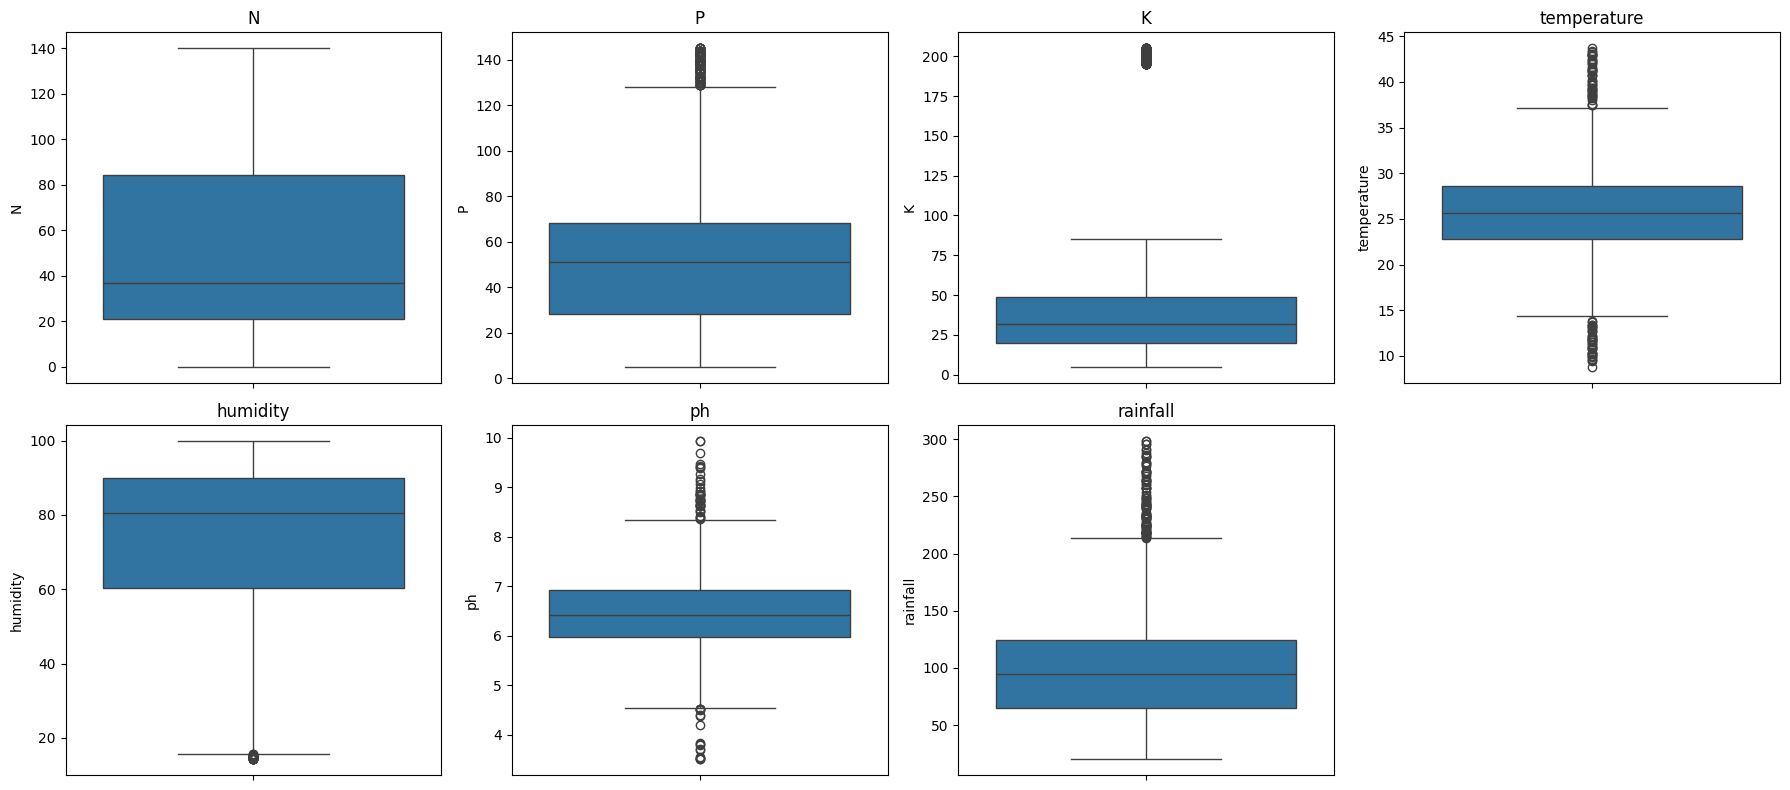

In [369]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

##  Preprocessing

In [370]:
FEATURE_COLS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[FEATURE_COLS].values
y_raw = df["label"].values

In [371]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
NUM_CLASSES = len(label_encoder.classes_)

In [372]:
NUM_CLASSES

22

In [373]:
label_encoder.classes_

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

In [374]:
from tensorflow.keras.utils import to_categorical

Y_onehot = to_categorical(y_encoded, NUM_CLASSES)

In [375]:
X_train_full, X_test, y_train_full, y_test, Y_train_full, Y_test = train_test_split( X, y_encoded, Y_onehot, test_size=0.20, random_state=SEED, stratify=y_encoded)

In [376]:
X_train, X_val, y_train, y_val, Y_train, Y_val = train_test_split(X_train_full,y_train_full,Y_train_full,test_size=0.20,random_state=SEED,stratify=y_train_full)

In [377]:
X_train.shape

(1408, 7)

In [378]:
X_val.shape

(352, 7)

In [379]:
X_test.shape

(440, 7)

In [380]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

##  MLP


In [381]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(128, 64, 32),activation="relu",solver="adam",learning_rate_init=0.001,max_iter=300,batch_size=32,random_state=SEED)
model.fit(X_train_scaled, y_train)

MLPClassifier(batch_size=32, hidden_layer_sizes=(128, 64, 32), max_iter=300,
              random_state=42)

In [382]:
y_pred = model.predict(X_test_scaled)

In [383]:
print(classification_report(y_test,y_pred_test,target_names=label_encoder.classes_,zero_division=0))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      1.00      0.98        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       0.95      1.00      0.98        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

In [384]:
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

Test Accuracy: 0.9863636363636363


## Confusion Matrix

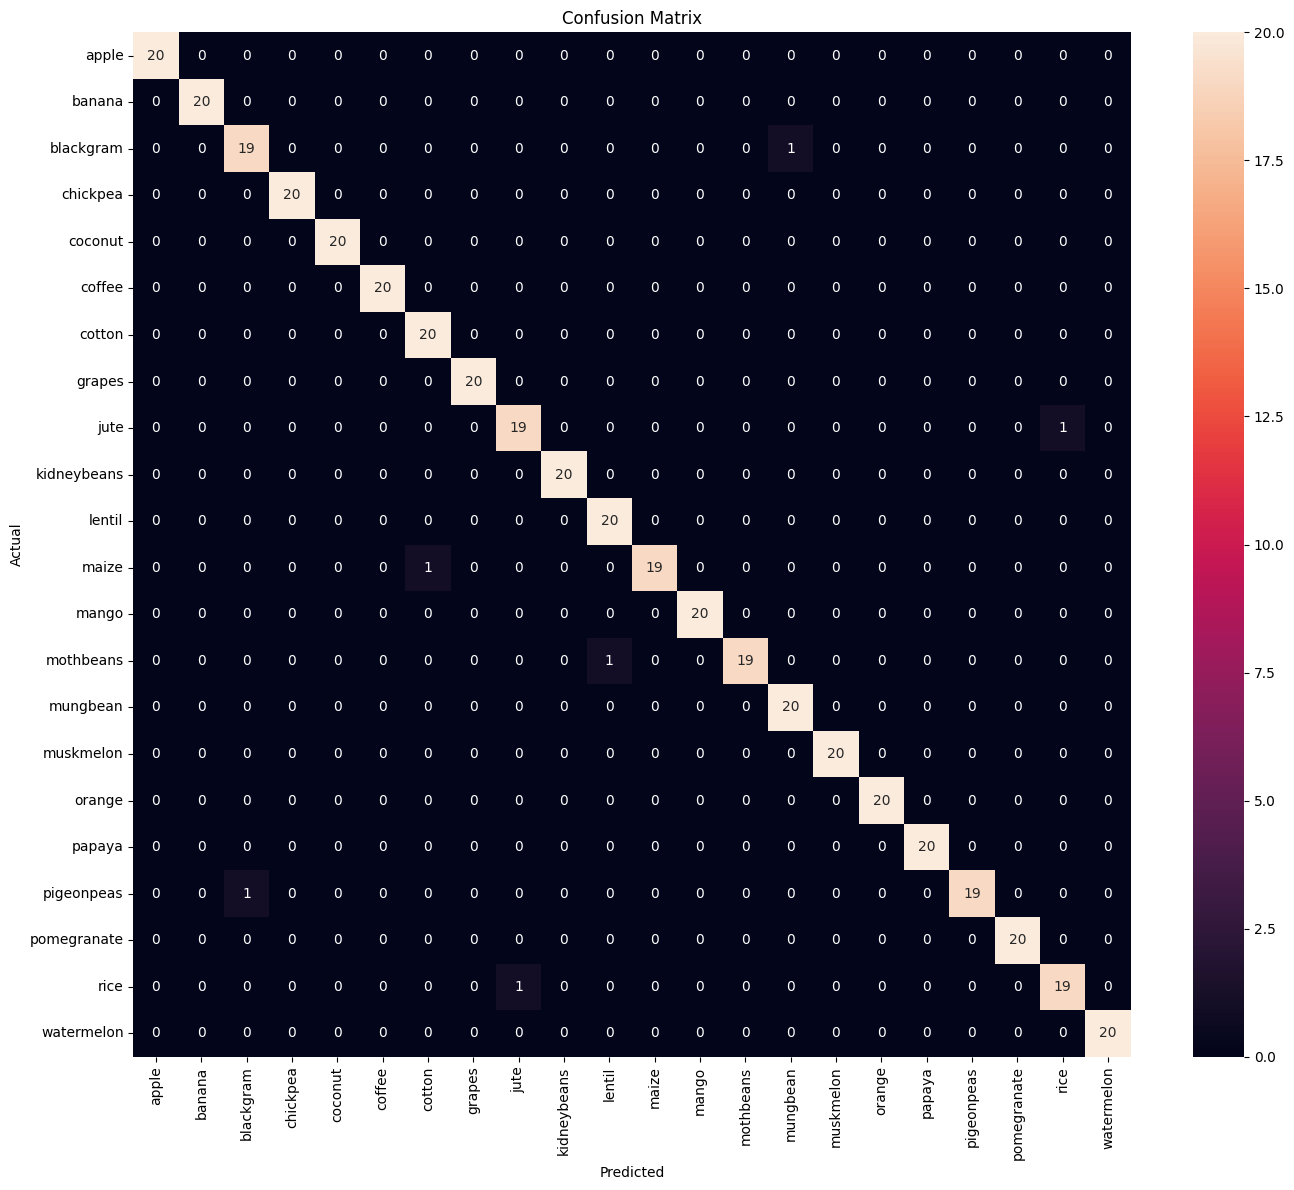

In [385]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(14, 12))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()